In [1]:
#Amo evaluation
#FM 28.11.2025
import sys
sys.path.append('amos') 
# Import all ML orchestration functions
from amos.ml_orchestration import (
    ml_exp_with_timing,  # Main experiment function with timing preservation
    extract_timing_structure,
    save_midi_with_exact_timing_structure,
    KerasClassifierWrapper,
    build_lstm_classifier,
    build_transformer_classifier,
    clf_predict,
    defineXy,           # Data preparation function
    split_and_encode    # Train/test split with encoding
)
# Import MIDI processing functions  
from amos.midi2df2midi import midi_to_dataframe, save_midi_from_df
from amos.mappings import fill_quaterna_columns, learn_quaterna_mapping
# Import amo funtion
from amos.ml_orchestration import amo_with_doublings_multiclass

import pandas as pd
import numpy as np
from collections import defaultdict


from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier

import matplotlib.pyplot as plt



/home/francesco/anaconda3/envs/auto-orch/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
2025-12-02 16:24:51.815157: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764689091.835008   98597 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been

In [2]:
# amo_with_doublings
# Args:
  #      filein (str): Path to the source MIDI file to learn orchestration style from.
  #      fileout (str): Path to the target MIDI file to be orchestrated.
  #      ytarget (str, optional): The target variable for the model ('track-channel' or 'program').
  #                               Defaults to "track-channel".
  #      model (str, optional): The name of the machine learning model to use for orchestration.
  #     ("XGBoost","RandomForest", "DecisionTree", "NearestNeighbors", "MLP3", "NaiveBayes", "MLP1", "AdaBoost", "LSTMClassifier", "TransformerClassifier")
  #                             Defaults to "XGBoost".

In [3]:
def transpose(note, inverse=False, n_semitones=12):
    # Example: transpose pitch
    if inverse:
        n_semitones = - n_semitones
    new_note = note.copy()
    new_note['pitch'] = note['pitch'] + n_semitones
    return [ new_note ]

In [4]:
transformations = [
    (transpose, {'n_semitones': 12}),
    (transpose, {'n_semitones': 24}),
    (transpose, {'n_semitones': 46}),
    (transpose, {'n_semitones': -12}),
    (transpose, {'n_semitones': -24}),
    (transpose, {'n_semitones': -46}),
    #(split_duration, {'smallest_unit': 0.25}),
]

In [5]:
"""
Prompt by GV
create a python function to read the path of .mid files which contain the string "orch". Files are inside folders like "folder_name1/la_mer_1_orch.mid", "folder_name2/symphony_9_2_orch.mid", etc.
"""
import os

def find_orch_mid_files(root_dir='.'):
    result = []
    for dirpath, _, filenames in os.walk(root_dir):
        for name in filenames:
            if name.lower().endswith('.mid') and 'orch' in name.lower():
                result.append(os.path.join(dirpath, name))
    return result

In [6]:
root_dir='LOP_database_06_09_17/hand_picked_Spotify'
filenames = find_orch_mid_files(root_dir)
len(filenames)

55

In [7]:
model_names = [
        "XGBoost",
        "RandomForest",
        "DecisionTree",
        #"LSTMClassifier",      # Added
        "NearestNeighbors",
        #"MLP3",   
        #"TransformerClassifier", # Added
        "NaiveBayes",
        "MLP1",
        "AdaBoost",
        "Dummy0",
        "Dummy1",
        "DummyUnif",      
    ]

model_names_short = [
    'XGB',
    'RF',
    'DT',
    #'LSTM*',
    'NN',
    #'MLP3*',
    #'TF',
    'NB',
    'MLP1',
    'AB',
    'D0',
    'D1',
    'DU',
    ]

classifiers = [
    XGBClassifier(),
    RandomForestClassifier(),
    DecisionTreeClassifier(),
    #KerasClassifierWrapper(build_lstm_classifier),      # Added LSTM
    KNeighborsClassifier(1),
    #MLPClassifier(hidden_layer_sizes=(128,128,128)),
    #KerasClassifierWrapper(build_transformer_classifier),# Added Transformer
    GaussianNB(),
    MLPClassifier(),
    AdaBoostClassifier(),
    DummyClassifier(strategy='constant', constant=0),
    DummyClassifier(strategy='constant', constant=1),
    DummyClassifier(strategy='uniform'),
]

In [8]:
# Reduce for testing purposes, remove this cell for the actual experiment
N_files = 3 #len(filenames)
N_models = len(classifiers)

filenames = filenames[:N_files]

model_names = model_names[:N_models]
classifiers = classifiers[:N_models]
model_names_short = model_names_short[:N_models]

In [9]:
# Initialize metrics collectors
s = (len(filenames),len(model_names))
ml_metrics = dict()
base_metrics_names = ["time",
                      "accuracy (train)",
                      "accuracy (test)",
                      "precision (train)",
                      "precision (test)",
                      "recall (train)",
                      "recall (test)",
                      "f1 (train)",
                      "f1 (test)",
                      ] #, "n_events", "n_classes"]
ml_metrics_names = base_metrics_names.copy()

for func, kwargs in transformations:
    trans_target_name = f"{func.__name__}_{kwargs}"
    for bmn in base_metrics_names:
        ml_metrics_names.append(f"{bmn} ({trans_target_name})")

for mn in ml_metrics_names:
    ml_metrics[mn] = np.zeros(s)

In [10]:
# Multiclass, with transformations
error_collection = []
for i, filein in enumerate(filenames):    
    for u, (model_name, clf) in enumerate(zip(model_names, classifiers)):
        try: 
            metrics = amo_with_doublings_multiclass(filein,fileout=None,model=model_name, tol=0.2, transformations=transformations)
            print(metrics)
            for mn in ml_metrics_names:
                # ml_metrics["accuracy"][i,u] = metrics["accuracy"]
                ml_metrics[mn][i,u] = metrics[mn]
        except Exception as e:
            print("Error")
            error_collection.append(f"Error with {filein} and model {model_name}: {e}")

print("\n????????? ERRORS ??????????")
for error in error_collection:
    print(error)

Learning orchestration style from: LOP_database_06_09_17/hand_picked_Spotify/58/swan_lake_26_orch.mid

========= PREPROCESSING =========
Mapping: [[1 'Piccolo' 1 73]
 [2 '2 Flauti' 1 73]
 [3 '2 Oboi' 2 68]
 [4 '2 Clarinetti in B' 3 71]
 [5 '2 Fagotti' 4 70]
 [6 'Corni in F I II' 5 60]
 [7 'Corni in F III IV' 5 60]
 [8 '2 Pistoni in B' 6 56]
 [9 '2 Trombe in F' 6 56]
 [10 '2 Tromboni' 7 57]
 [11 'Trombone 3' 7 57]
 [12 'Tuba' 8 58]
 [13 'Timpani' 10 47]
 [14 'Arpa' 0 46]
 [15 'Violine I' 11 45]
 [15 'Violine I' 11 48]
 [16 'Violine II' 12 48]
 [17 'Viola' 13 45]
 [17 'Viola' 13 48]
 [18 'Violoncelle' 14 45]
 [18 'Violoncelle' 14 48]
 [19 'Contrabasse' 15 45]
 [19 'Contrabasse' 15 48]]

Building reduced dataset with transformations
{'transformed': 308, 'direct': 39, 'none': 3973}
Original size: (4320, 15)
Dropping [901, 902, 903, 905, 906, 907, 909, 911, 913, 915, 916, 917, 919, 921, 923, 925, 927, 929, 930, 932, 936, 945, 946, 949, 479, 960, 711, 713, 715, 487, 968, 496, 498, 500, 502, 

/home/francesco/anaconda3/envs/auto-orch/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Train Time (sec): 67.8914
Score on Test (20%): 0.4441
Precision (micro): 0.7923
Recall (micro): 0.4763
F1-Score (micro): 0.5949
Confusion Matrices for Individual Classes:
--- Class: 10_7 2 Tromboni ---
[[844   0]
 [  5   0]]
--- Class: 11_7 Trombone 3 ---
[[844   0]
 [  5   0]]
--- Class: 12_8 Tuba ---
[[838   7]
 [  0   4]]
--- Class: 13_10 Timpani ---
[[632   0]
 [  4 213]]
--- Class: 14_0 Arpa ---
[[812   0]
 [  0  37]]
--- Class: 15_11 Violine I ---
[[785   0]
 [ 57   7]]
--- Class: 16_12 Violine II ---
[[733  36]
 [ 52  28]]
--- Class: 17_13 Viola ---
[[758   0]
 [ 91   0]]
--- Class: 18_14 Violoncelle ---
[[750  26]
 [ 30  43]]
--- Class: 19_15 Contrabasse ---
[[794  21]
 [  0  34]]
--- Class: 1_1 Piccolo ---
[[845   0]
 [  4   0]]
--- Class: 2_1 2 Flauti ---
[[819   3]
 [ 12  15]]
--- Class: 3_2 2 Oboi ---
[[791   3]
 [ 35  20]]
--- Class: 4_3 2 Clarinetti in B ---
[[814  10]
 [ 18   7]]
--- Class: 5_4 2 Fagotti ---
[[794   2]
 [ 50   3]]
--- Class: 6_5 Corni in F I II ---
[[805

/home/francesco/anaconda3/envs/auto-orch/lib/python3.12/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Train Time (sec): 0.0772
Score on Test Set (20% split): 1.0000
Precision (weighted): 1.0000
Recall (weighted): 1.0000
F1-Score (weighted): 1.0000
Confusion Matrix:
 [[1268]]
Pipeline saved: transpose_{'n_semitones': -24}.joblib
transpose_{'n_semitones': -46}
0    1.0
Name: proportion, dtype: float64
Labels [0]
Number of events: 6337
Last onset at 310.14166666666665
Only one label in target variable
{'time': 2.3551487922668457, 'accuracy (test)': np.float64(0.8499245852187028), 'accuracy (train)': np.float64(0.9130844645550528), 'precision (test)': 0.8763961280714817, 'precision (train)': 0.9348880597014926, 'recall (test)': 0.8616398243045388, 'recall (train)': 0.9223265230995766, 'f1 (test)': 0.8689553340716132, 'f1 (train)': 0.9285648105253405, "time (transpose_{'n_semitones': 12})": 0.09748578071594238, "accuracy (test) (transpose_{'n_semitones': 12})": 0.9976340694006309, "accuracy (train) (transpose_{'n_semitones': 12})": 0.9986190570132176, "precision (test) (transpose_{'n_semito

...

{'transformed': 320, 'direct': 142, 'none': 6337}
Original size: (6799, 15)
Dropping [4265, 3105, 3106, 3453, 4833, 4834, 3762, 2949, 5414, 5415, 1636, 3343, 4860, 5536, 5537, 4958, 691, 4388, 4959, 4960, 4961, 2950, 5540, 3344, 5541, 5544, 5545, 4974, 3486, 4975, 4976, 5548, 5549, 5552, 5553, 5556, 5557, 5560, 5561, 5564, 5565, 5568, 3530, 3532, 5569, 5572, 5573, 5004, 726, 4433, 5005, 5006, 5007, 2951, 5576, 3345, 5577, 5580, 5581, 5020, 3558, 5021, 5022, 5584, 5585, 5588, 5589, 5592, 5593, 5596, 5597, 5600, 5601, 5604, 3602, 3604, 5605, 5608, 5609, 2279, 2281, 2283, 2285, 2287, 2289, 2291, 4476, 2293, 5615, 3906, 5076, 3954, 5118, 5135, 5136, 5137, 5138, 5139, 5140, 5141, 5142, 5143, 5144, 5145, 5146, 5147, 5148, 5149, 5150, 5151, 5152, 5153, 5154, 5155, 5156, 5157, 5158, 5159, 5160, 5161, 5162, 5163, 3632, 5164, 5165, 5166, 5167, 5168, 5169, 3635, 5170, 5171, 5172, 5173, 5174, 5175, 5176, 5177, 5178, 5179, 5180, 5181, 5182, 5183, 5184, 5185, 3647, 5186, 5187, 5188, 5189, 5190, 5191

/home/francesco/anaconda3/envs/auto-orch/lib/python3.12/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Train Time (sec): 0.0824
Score on Test Set (20% split): 1.0000
Precision (weighted): 1.0000
Recall (weighted): 1.0000
F1-Score (weighted): 1.0000
Confusion Matrix:
 [[1268]]
Pipeline saved: transpose_{'n_semitones': -24}.joblib
transpose_{'n_semitones': -46}
0    1.0
Name: proportion, dtype: float64
Labels [0]
Number of events: 6337
Last onset at 310.14166666666665
Only one label in target variable
{'time': 0.024877071380615234, 'accuracy (test)': np.float64(0.0), 'accuracy (train)': np.float64(0.0), 'precision (test)': 0.05150829562594268, 'precision (train)': 0.05121606334841629, 'recall (test)': 1.0, 'recall (train)': 1.0, 'f1 (test)': 0.09797030768127375, 'f1 (train)': 0.09744155389954534, "time (transpose_{'n_semitones': 12})": 0.10363388061523438, "accuracy (test) (transpose_{'n_semitones': 12})": 0.9976340694006309, "accuracy (train) (transpose_{'n_semitones': 12})": 0.9986190570132176, "precision (test) (transpose_{'n_semitones': 12})": 0.9981072555205046, "precision (train) (t

/home/francesco/anaconda3/envs/auto-orch/lib/python3.12/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Train Time (sec): 0.0603
Score on Test Set (20% split): 1.0000
Precision (weighted): 1.0000
Recall (weighted): 1.0000
F1-Score (weighted): 1.0000
Confusion Matrix:
 [[1268]]
Pipeline saved: transpose_{'n_semitones': -24}.joblib
transpose_{'n_semitones': -46}
0    1.0
Name: proportion, dtype: float64
Labels [0]
Number of events: 6337
Last onset at 310.14166666666665
Only one label in target variable
{'time': 0.026068925857543945, 'accuracy (test)': np.float64(0.0), 'accuracy (train)': np.float64(0.0), 'precision (test)': 0.053346486568523296, 'precision (train)': 0.05188883655204899, 'recall (test)': 0.5146412884333821, 'recall (train)': 0.5069022639425732, 'f1 (test)': 0.09667216721672167, 'f1 (train)': 0.09414097217474533, "time (transpose_{'n_semitones': 12})": 0.08276867866516113, "accuracy (test) (transpose_{'n_semitones': 12})": 0.9976340694006309, "accuracy (train) (transpose_{'n_semitones': 12})": 0.9986190570132176, "precision (test) (transpose_{'n_semitones': 12})": 0.99810725

In [11]:
def return_m_std(ml_metrics, metric_name):
    print(metric_name)
    mean = np.mean(ml_metrics, axis=0)
    std = np.std(ml_metrics, axis=0)
    print(mean)
    print(std)
    return mean, std

In [12]:
metrics_mean = dict()
metrics_std = dict()
for mn in ml_metrics_names:
    metrics_mean[mn], metrics_std[mn] = return_m_std(ml_metrics[mn], mn)

time
[3.46787143e+00 8.57711061e+00 2.20246156e-01 1.23597855e+01
 1.44428253e-01 1.32061609e+02 7.66348235e+00 2.38211950e-02
 2.92563438e-02 3.08269660e-02]
[1.83979776e+00 5.39073135e+00 1.47525113e-01 7.21184217e+00
 7.94237625e-02 6.47021523e+01 3.59256268e+00 7.29146963e-03
 1.15048763e-02 1.19850464e-02]
accuracy (train)
[0.88142168 0.99992617 1.         1.         0.2471712  0.30878402
 0.44461826 0.         0.         0.        ]
[8.29744160e-02 1.04408532e-04 0.00000000e+00 0.00000000e+00
 6.80905797e-02 1.22043673e-01 1.38886574e-01 0.00000000e+00
 0.00000000e+00 0.00000000e+00]
accuracy (test)
[0.77984331 0.77728147 0.74867432 0.75784219 0.24814599 0.31146184
 0.44123966 0.         0.         0.        ]
[0.10365177 0.08210927 0.09477762 0.12505234 0.07175437 0.12364362
 0.13715837 0.         0.         0.        ]
precision (train)
[0.95009999 1.         1.         1.         0.39366419 0.65314249
 0.83513143 0.         0.06251712 0.06259136]
[0.02730576 0.         0.     

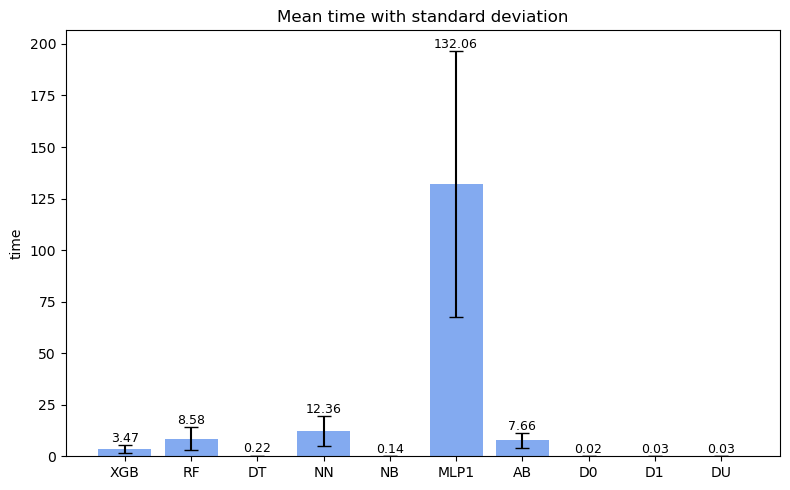

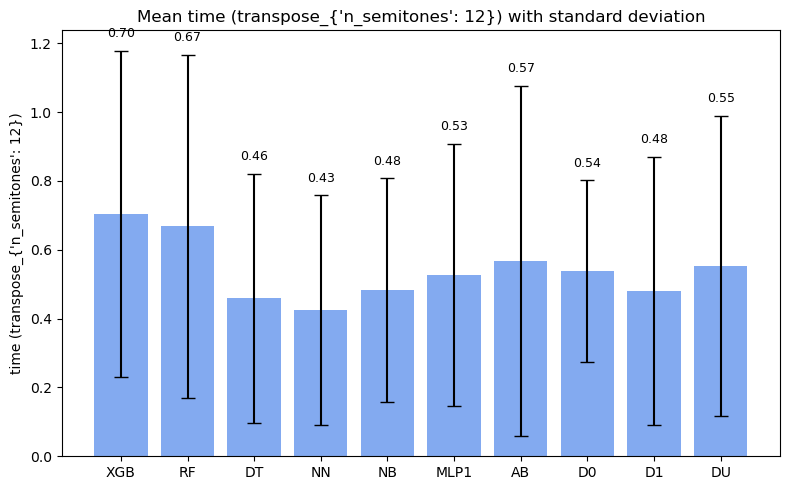

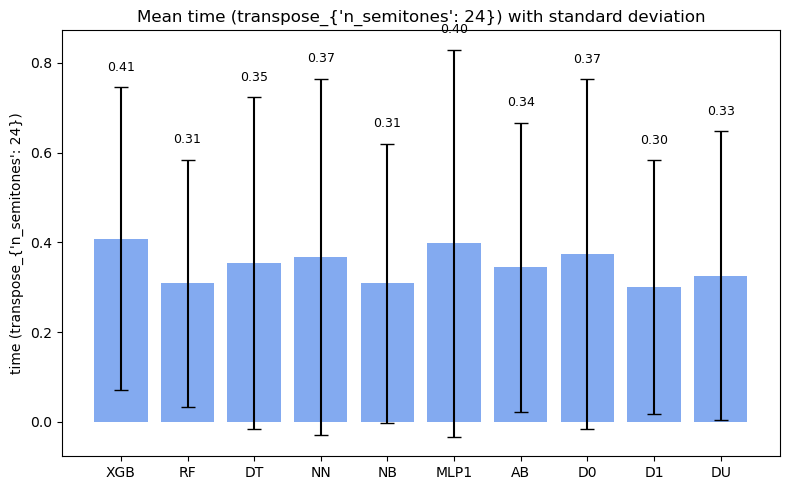

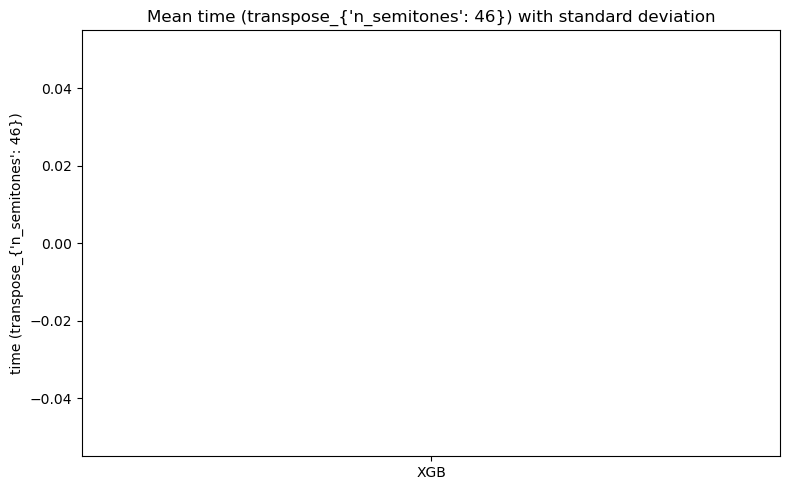

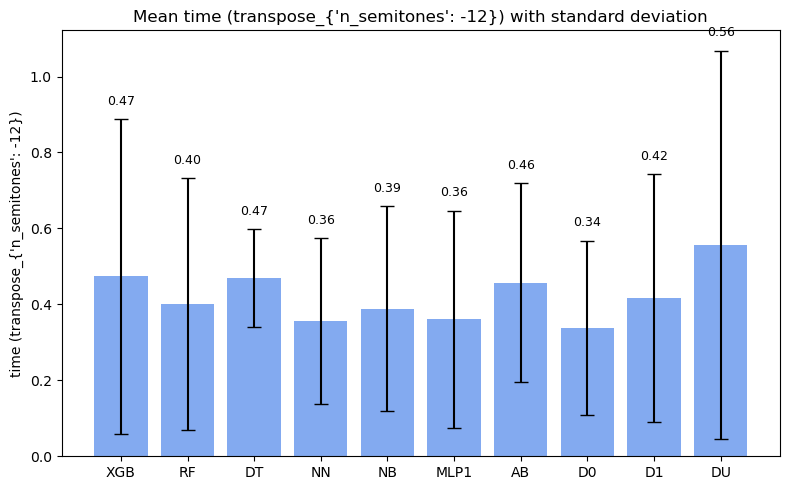

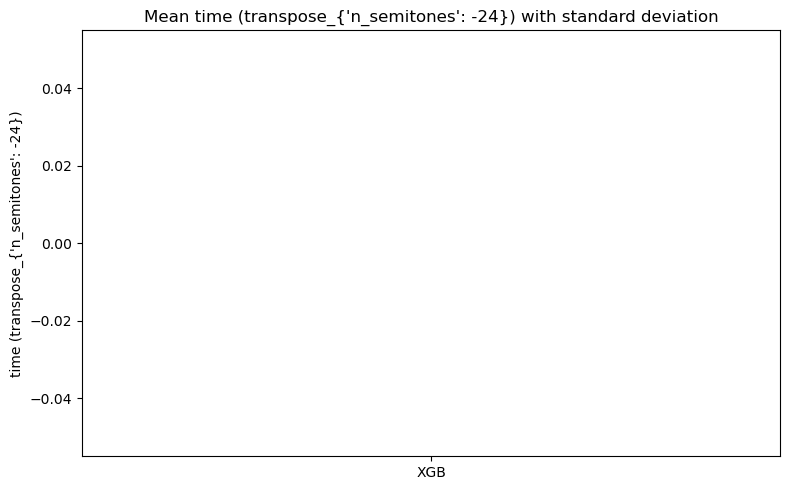

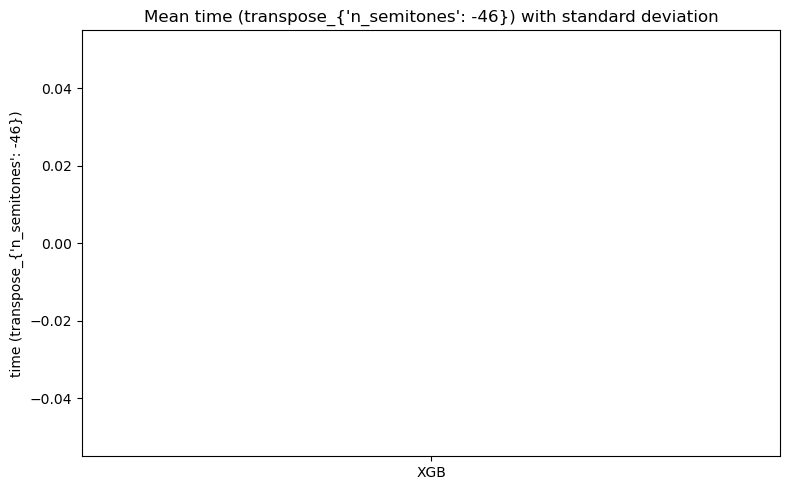

In [13]:
for mn in ml_metrics_names:
    if "time" in mn:
        # Plot
        plt.figure(figsize=(8, 5))
        barlist = plt.bar(model_names_short, metrics_mean[mn], yerr=metrics_std[mn], capsize=5, color='cornflowerblue', alpha=0.8)

        plt.ylabel(mn)
        plt.title(f'Mean {mn} with standard deviation')
        if not "time" in mn:
            plt.ylim(0, 1.1)

        # Optional: Add mean values above bars
        for i, (mean, std) in enumerate(zip(metrics_mean[mn], metrics_std[mn])):
            plt.text(i, mean + std + 0.03, f"{mean:.2f}", ha='center', va='bottom', fontsize=9)

        plt.tight_layout()
        plt.show()

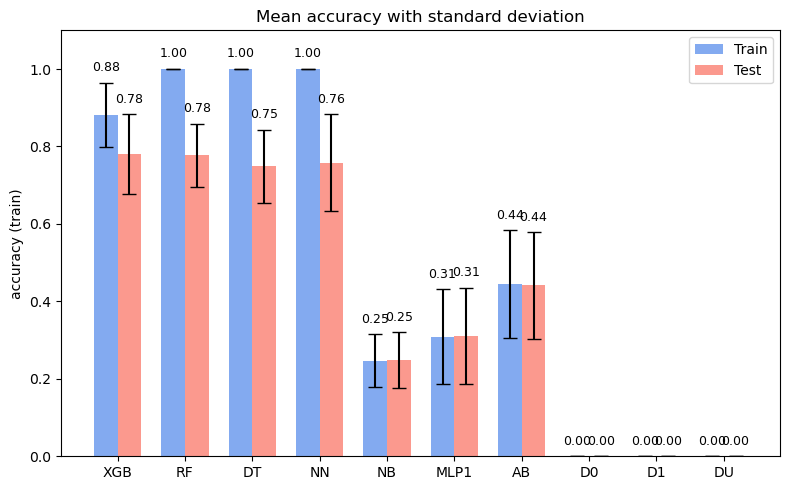

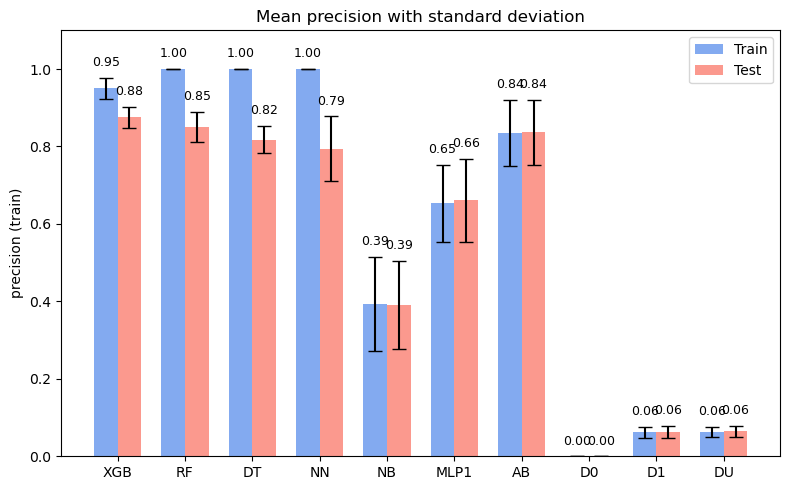

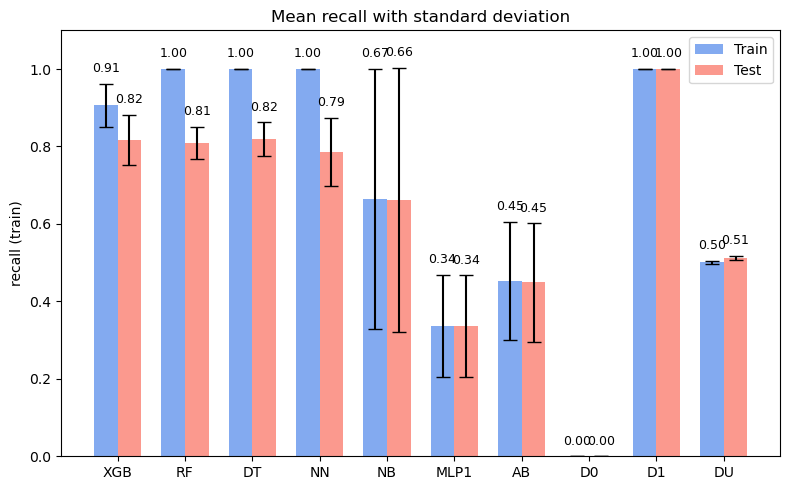

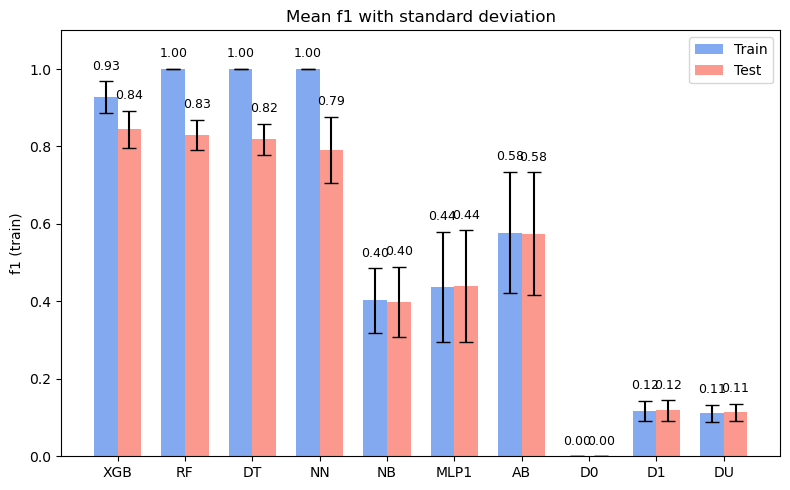

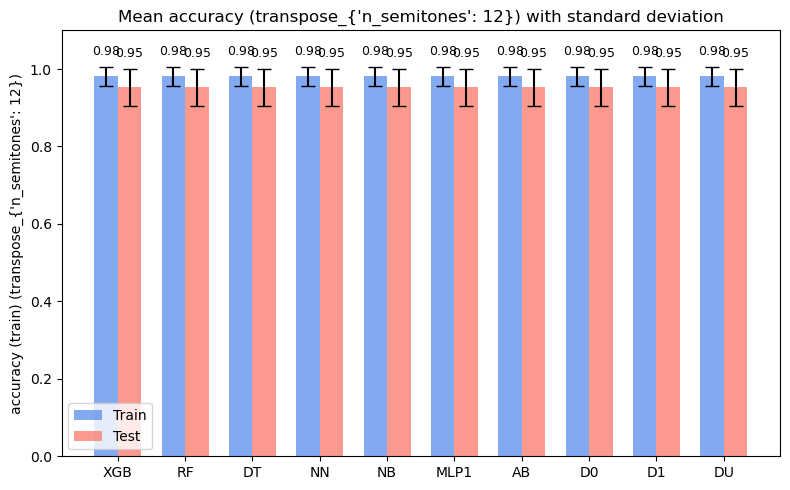

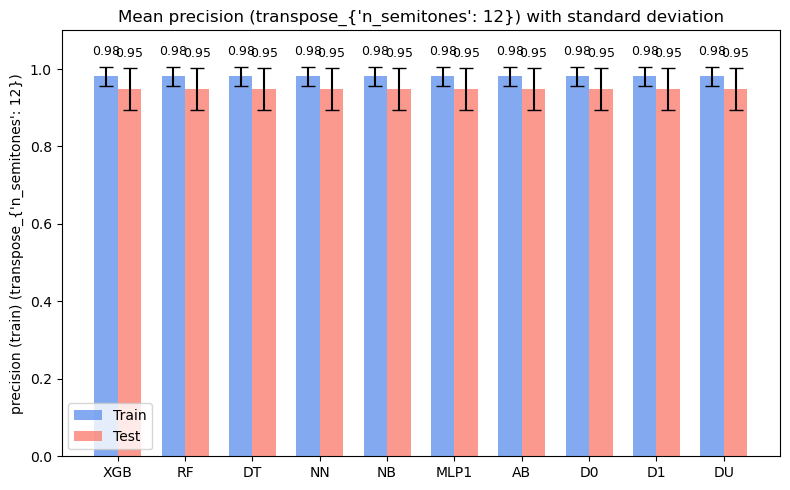

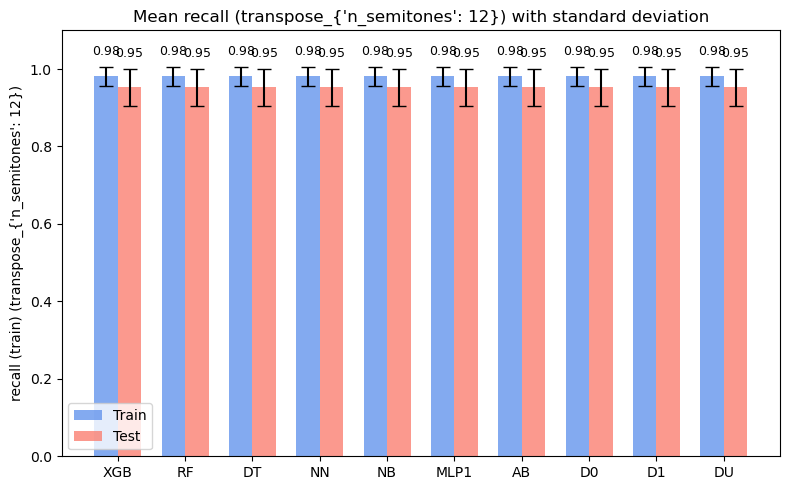

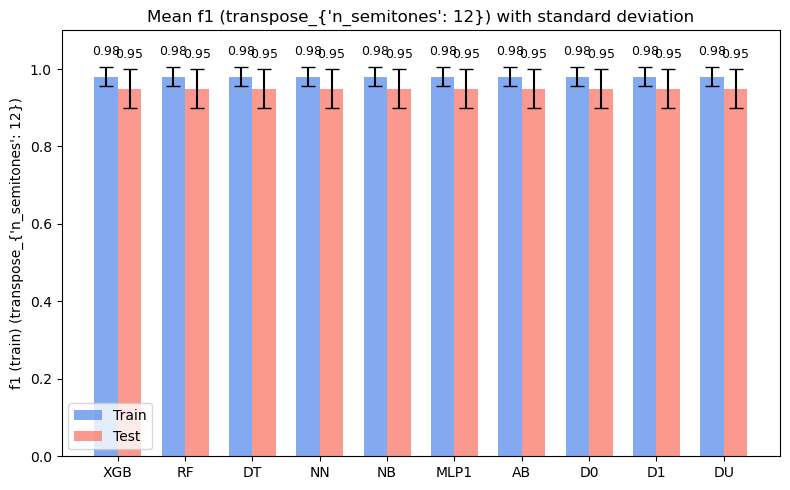

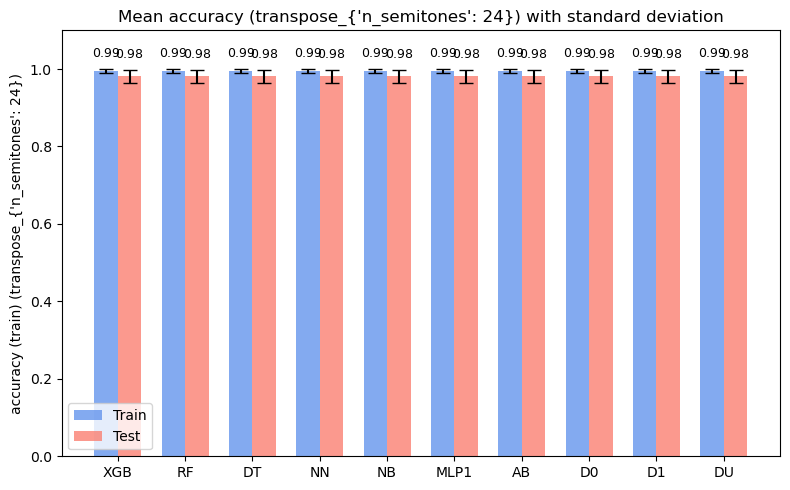

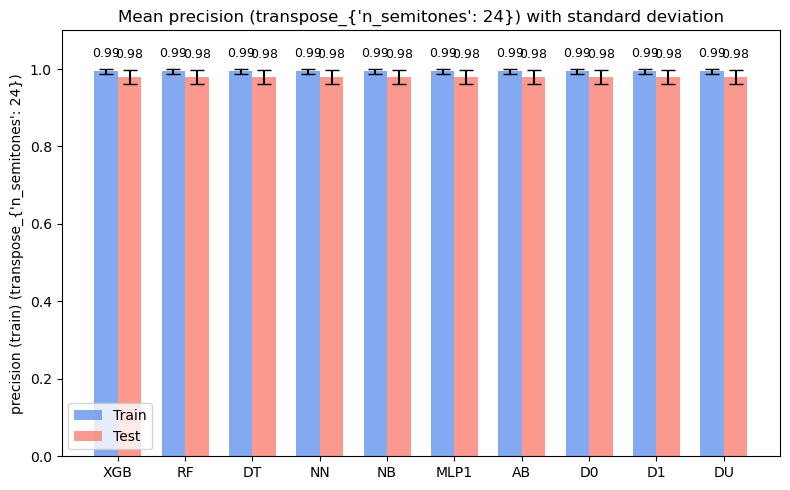

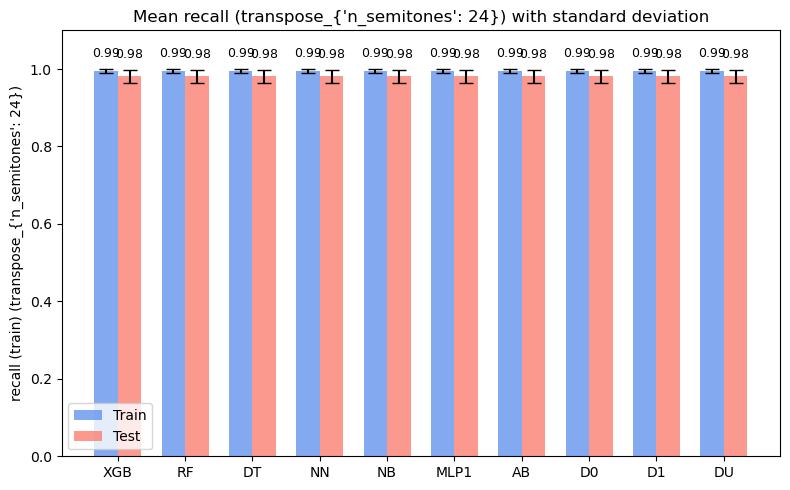

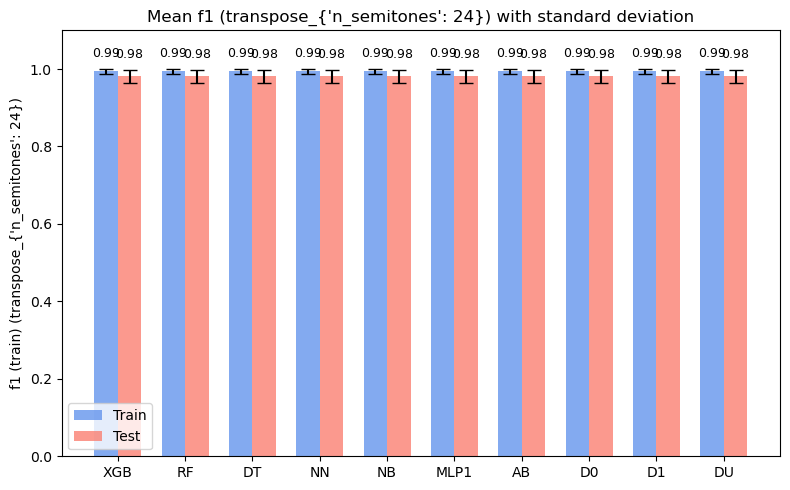

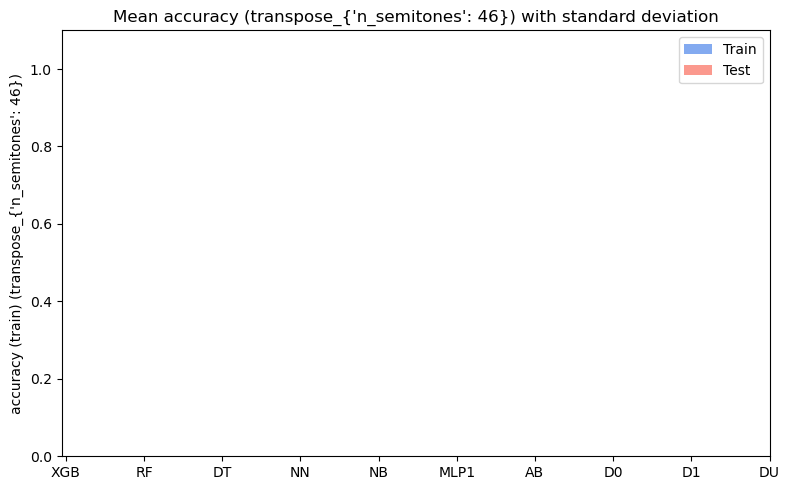

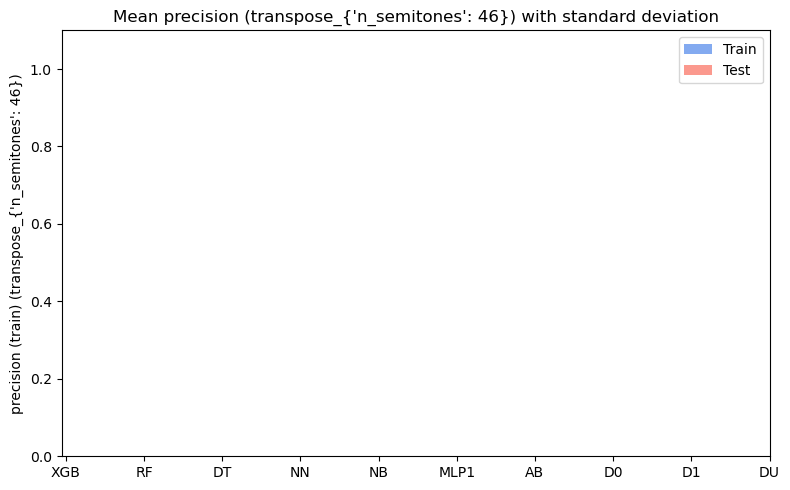

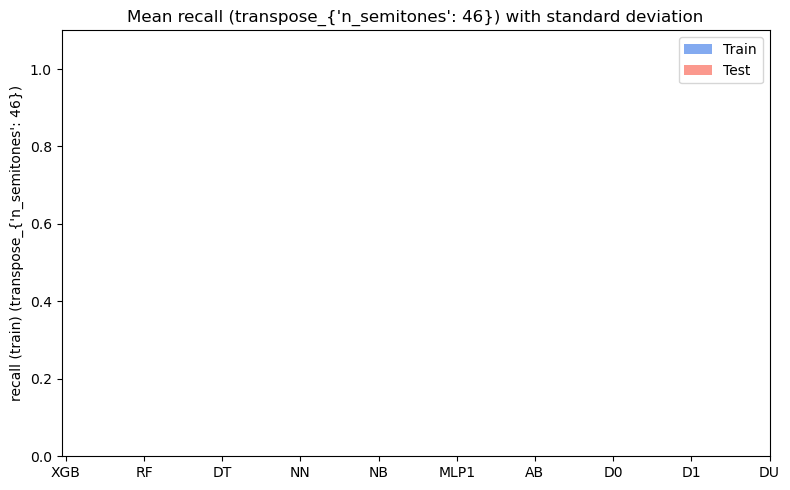

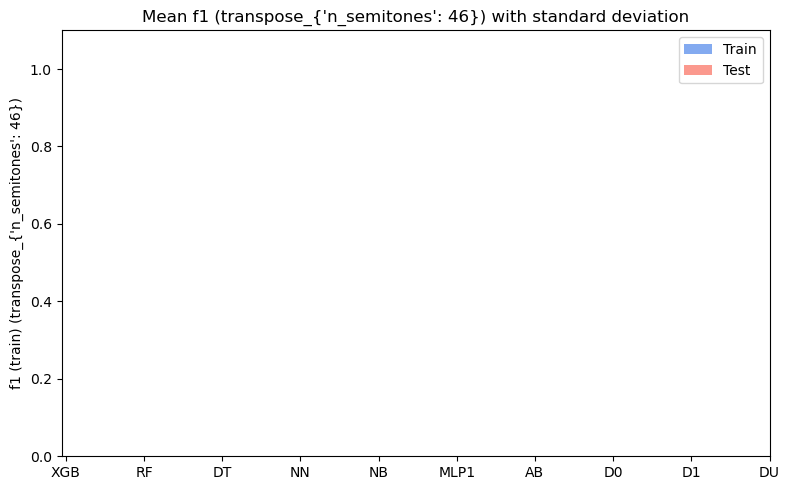

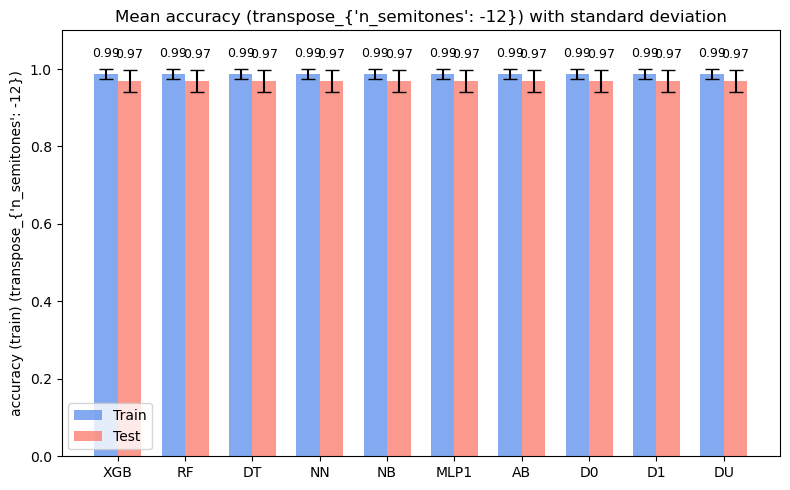

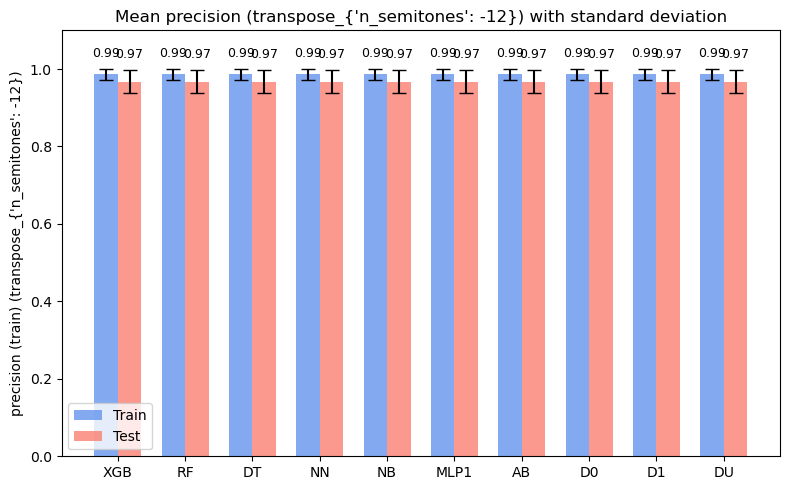

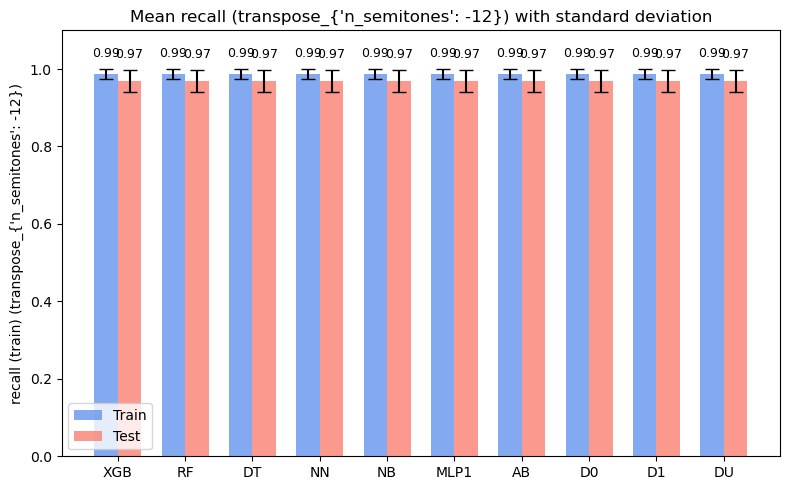

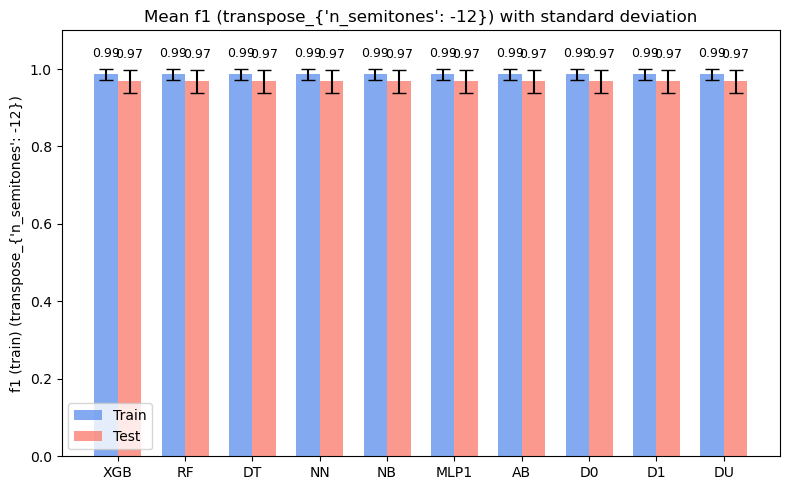

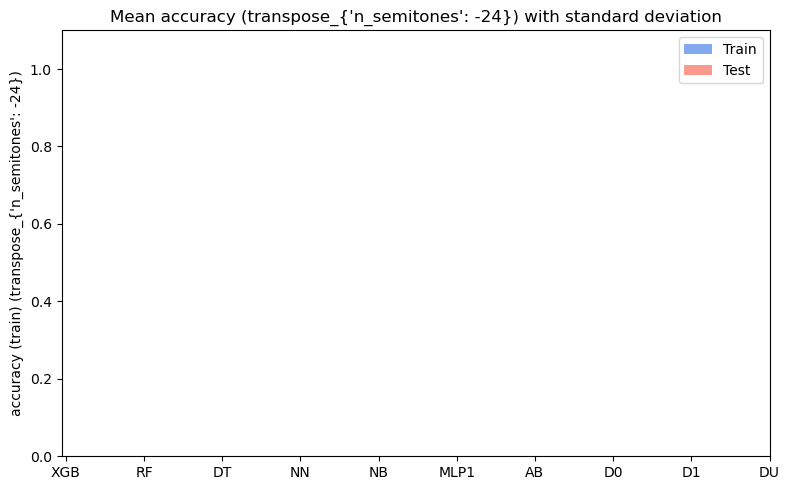

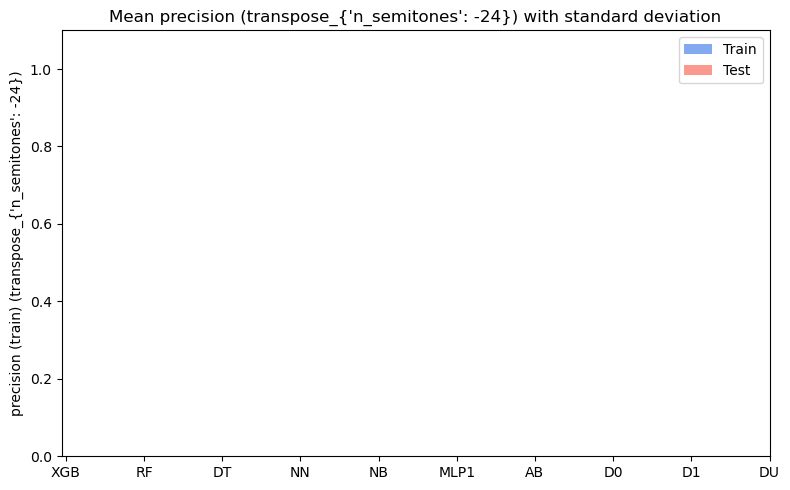

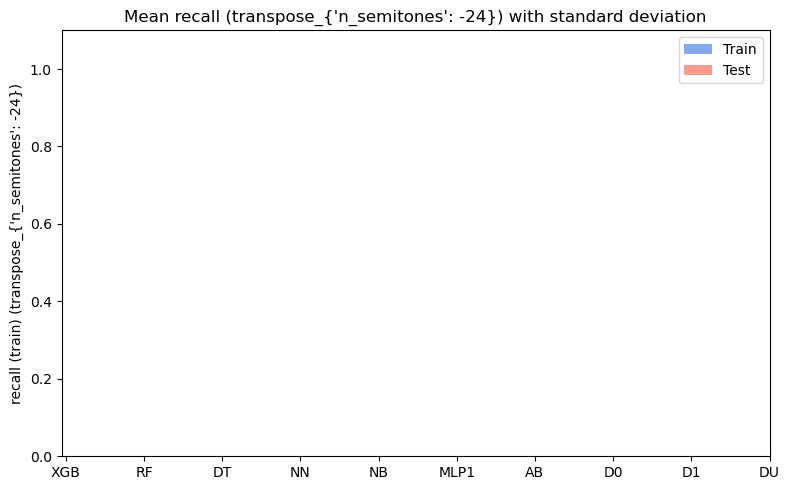

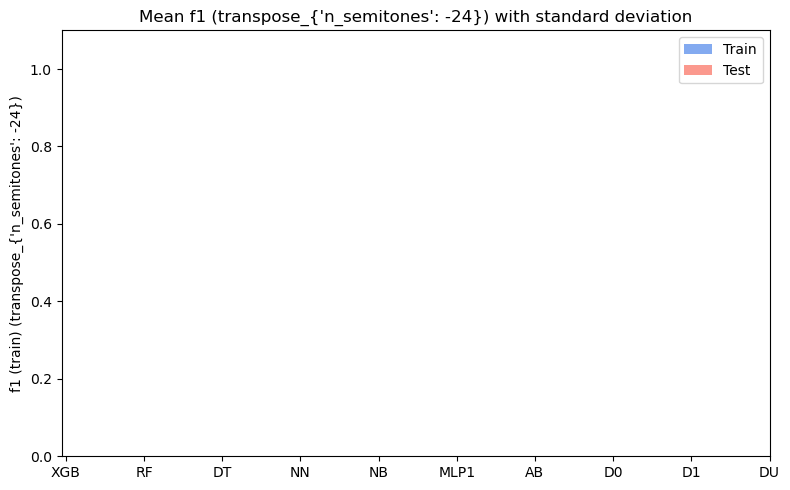

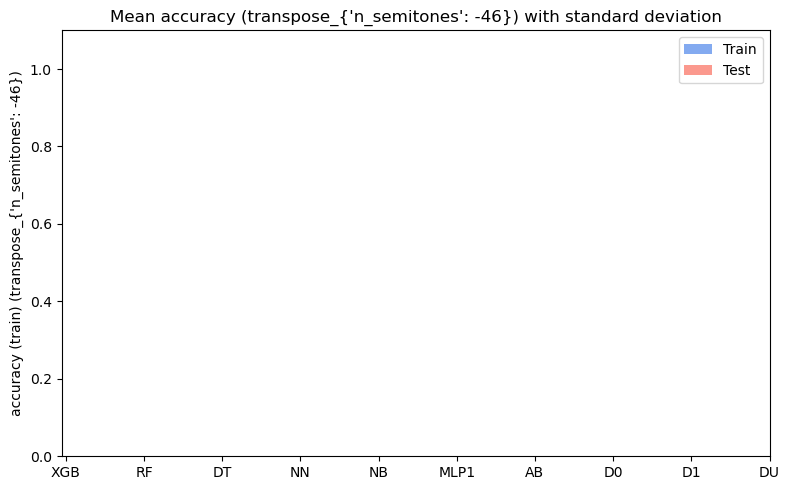

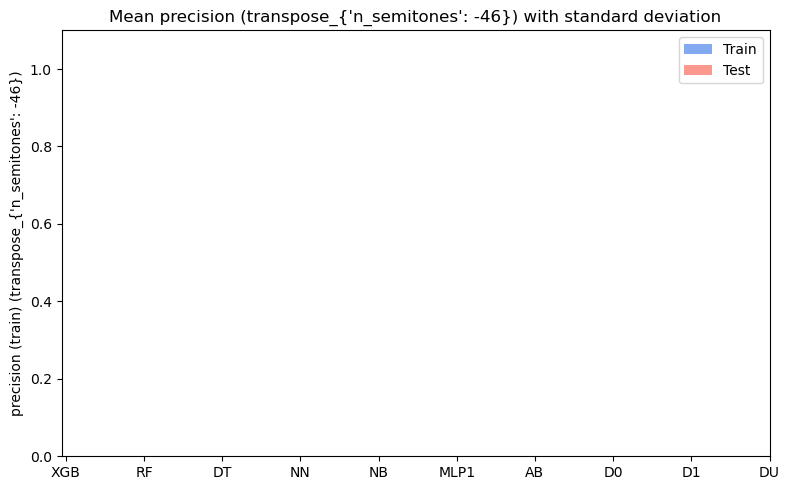

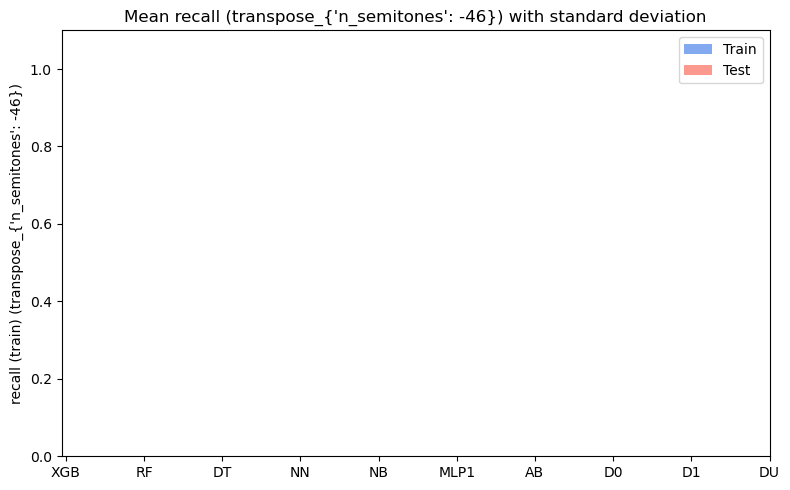

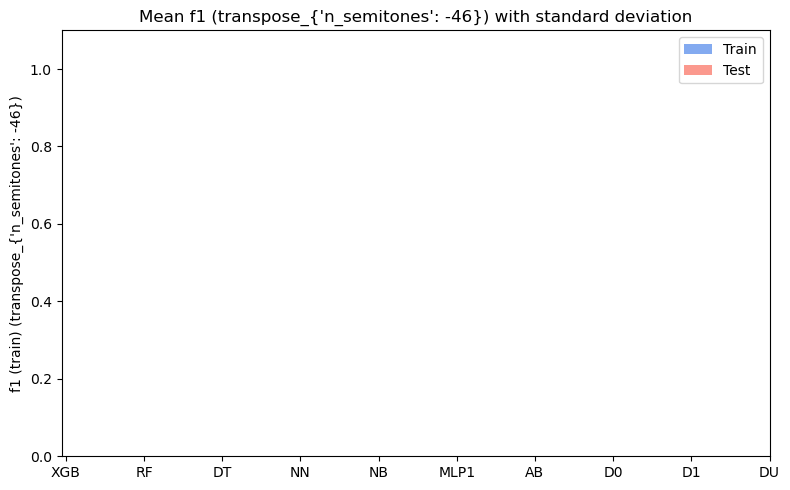

In [14]:
for mn in ml_metrics_names:
    if "train" in mn:
        mn_train = mn
        mn_test = mn.replace("train", "test")

        # Data for the two series
        train_means = metrics_mean[mn_train]
        test_means  = metrics_mean[mn_test]
        train_stds  = metrics_std[mn_train]
        test_stds   = metrics_std[mn_test]

        x = np.arange(len(model_names_short))   # positions
        width = 0.35

        plt.figure(figsize=(8, 5))

        # Two bar groups
        plt.bar(x - width/2, train_means, width,
                yerr=train_stds, capsize=5,
                label='Train', color='cornflowerblue', alpha=0.8)

        plt.bar(x + width/2, test_means, width,
                yerr=test_stds, capsize=5,
                label='Test', color='salmon', alpha=0.8)

        # Labels & layout
        plt.xticks(x, model_names_short)
        plt.ylabel(mn)
        plt.title(f'Mean {mn.replace(" (train)", "")} with standard deviation')

        if "time" not in mn:
            plt.ylim(0, 1.1)

        # Add mean value labels above bars
        for i, (mean, std) in enumerate(zip(train_means, train_stds)):
            plt.text(x[i] - width/2, mean + std + 0.03, f"{mean:.2f}",
                    ha='center', fontsize=9)

        for i, (mean, std) in enumerate(zip(test_means, test_stds)):
            plt.text(x[i] + width/2, mean + std + 0.03, f"{mean:.2f}",
                    ha='center', fontsize=9)

        plt.legend()
        plt.tight_layout()
        plt.show()